# Tampa Bay Water Quality — Data Exploration
Exploring USGS real-time water sensor data for Tampa Bay area stations.
Goal: understand what data is available before building anything.

In [1]:
import requests

url = "https://waterservices.usgs.gov/nwis/iv/"

response = requests.get(url, params={
    "sites": "02301721",
    "parameterCd": "00095",
    "format": "json",
    "period": "P1D"
})

print(response.status_code)
print(response.json().keys())

200
dict_keys(['name', 'declaredType', 'scope', 'value', 'nil', 'globalScope', 'typeSubstituted'])


In [2]:
# dig into the structure
data = response.json()
ts = data["value"]["timeSeries"]
print(f"number of time series: {len(ts)}")
print(ts[0].keys())

number of time series: 1
dict_keys(['sourceInfo', 'variable', 'values', 'name'])


In [3]:
# what station and parameter is this?
print(ts[0]["sourceInfo"]["siteName"])
print(ts[0]["variable"]["variableName"])
print(ts[0]["variable"]["unit"]["unitCode"])

ALAFIA RIVER AT GIBSONTON FL
Specific conductance, water, unfiltered, microsiemens per centimeter at 25&#176;C
uS/cm @25C


In [4]:
# look at the actual readings
values = ts[0]["values"][0]["value"]
print(f"total readings: {len(values)}")
print("first few:", values[:3])
print("last few:", values[-3:])

total readings: 92
first few: [{'value': '46800', 'qualifiers': ['P'], 'dateTime': '2026-03-09T13:00:00.000-04:00'}, {'value': '46800', 'qualifiers': ['P'], 'dateTime': '2026-03-09T13:15:00.000-04:00'}, {'value': '46600', 'qualifiers': ['P'], 'dateTime': '2026-03-09T13:30:00.000-04:00'}]
last few: [{'value': '46800', 'qualifiers': ['P'], 'dateTime': '2026-03-10T11:15:00.000-04:00'}, {'value': '46800', 'qualifiers': ['P'], 'dateTime': '2026-03-10T11:30:00.000-04:00'}, {'value': '46900', 'qualifiers': ['P'], 'dateTime': '2026-03-10T11:45:00.000-04:00'}]


In [5]:
import pandas as pd

# put into a dataframe to work with it more easily
df = pd.DataFrame(values)
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["dateTime"] = pd.to_datetime(df["dateTime"])
df = df.rename(columns={"dateTime": "timestamp"})
df = df[["timestamp", "value"]]

print(df.shape)
df.head()

(92, 2)


,timestamp,value
0,2026-03-09 13:00:00-04:00,46800
1,2026-03-09 13:15:00-04:00,46800
2,2026-03-09 13:30:00-04:00,46600
3,2026-03-09 13:45:00-04:00,46700
4,2026-03-09 14:00:00-04:00,46600


In [6]:
# any missing values?
print(df.isnull().sum())
print(df.describe())

timestamp    0
value        0
dtype: int64
              value
count     92.000000
mean   45530.434783
std     1650.290626
min    40100.000000
25%    44350.000000
50%    46550.000000
75%    46700.000000
max    47100.000000


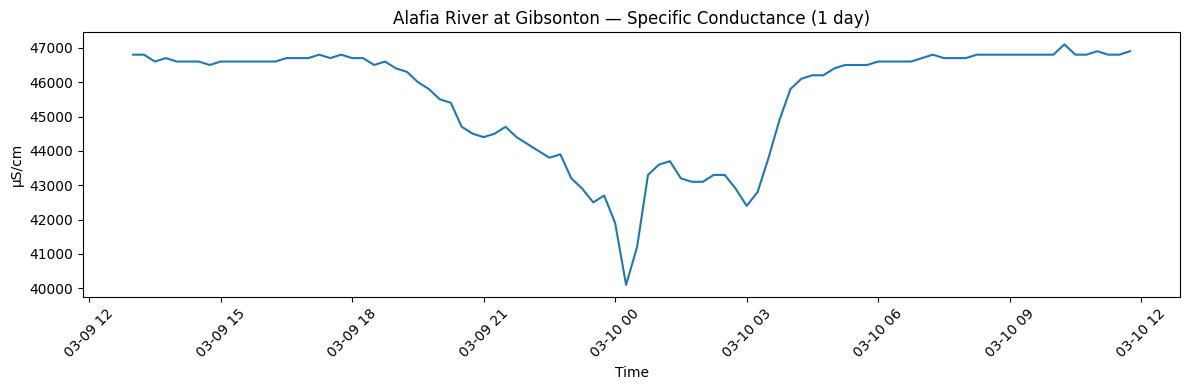

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["value"])
plt.title("Alafia River at Gibsonton — Specific Conductance (1 day)")
plt.xlabel("Time")
plt.ylabel("µS/cm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# now pull all 5 Tampa Bay stations + multiple parameters for 30 days
# 00095 = specific conductance (salinity proxy)
# 63680 = turbidity
# 00010 = temperature
# 00300 = dissolved oxygen

stations = {
    "023000095": "Manatee River at Rye",
    "02301721":  "Alafia River at Gibsonton",
    "02301718":  "Alafia River at Riverview",
    "02306028":  "Hillsborough River at Tampa",
    "02301500":  "Alafia River at Lithia",
}

response2 = requests.get(url, params={
    "sites": ",".join(stations.keys()),
    "parameterCd": "00095,63680,00010,00300",
    "format": "json",
    "period": "P30D"
})

data2 = response2.json()
ts2 = data2["value"]["timeSeries"]
print(f"got {len(ts2)} time series back")

got 12 time series back


In [9]:
# parse all of them into one dataframe
frames = []

for series in ts2:
    site_name = series["sourceInfo"]["siteName"]
    param_name = series["variable"]["variableName"].split(",")[0]
    param_code = series["variable"]["variableCode"][0]["value"]
    readings = series["values"][0]["value"]

    if not readings:
        continue

    tmp = pd.DataFrame(readings)
    tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
    tmp["dateTime"] = pd.to_datetime(tmp["dateTime"])
    tmp["station"] = site_name
    tmp["parameter"] = param_name
    tmp["param_code"] = param_code
    frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
df_all = df_all[df_all["value"] != -999999]  # USGS uses this for missing

print(df_all.shape)
print(df_all[["station", "parameter"]].drop_duplicates())

/var/folders/yh/9yrr73nj3419vqz3mxj3y33r0000gn/T/ipykernel_47831/627234183.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  tmp["dateTime"] = pd.to_datetime(tmp["dateTime"])
/var/folders/yh/9yrr73nj3419vqz3mxj3y33r0000gn/T/ipykernel_47831/627234183.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  tmp["dateTime"] = pd.to_datetime(tmp["dateTime"])
/var/folders/yh/9yrr73nj3419vqz3mxj3y33r0000gn/T/ipykernel_47831/627234183.py:15: FutureWarn

(34059, 6)
                                                 station             parameter
0                                MANATEE RIVER AT RYE FL           Temperature
2874                             MANATEE RIVER AT RYE FL  Specific conductance
5748   ALAFIA RIVER AT LITHIA PINECREST RD AT LITHIA, FL           Temperature
8503   ALAFIA RIVER AT LITHIA PINECREST RD AT LITHIA, FL  Specific conductance
11258  ALAFIA RIVER AT LITHIA PINECREST RD AT LITHIA, FL      Dissolved oxygen
14123  ALAFIA RIVER AT LITHIA PINECREST RD AT LITHIA, FL             Turbidity
16875            ALAFIA RIVER AT US 301 AT RIVERVIEW, FL           Temperature
19730            ALAFIA RIVER AT US 301 AT RIVERVIEW, FL  Specific conductance
22584                       ALAFIA RIVER AT GIBSONTON FL           Temperature
25453                       ALAFIA RIVER AT GIBSONTON FL  Specific conductance
28322     HILLSBOROUGH RIVER AT PLATT STREET AT TAMPA FL           Temperature
31190     HILLSBOROUGH RIVER AT PLATT STR

/var/folders/yh/9yrr73nj3419vqz3mxj3y33r0000gn/T/ipykernel_47831/627234183.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  tmp["dateTime"] = pd.to_datetime(tmp["dateTime"])


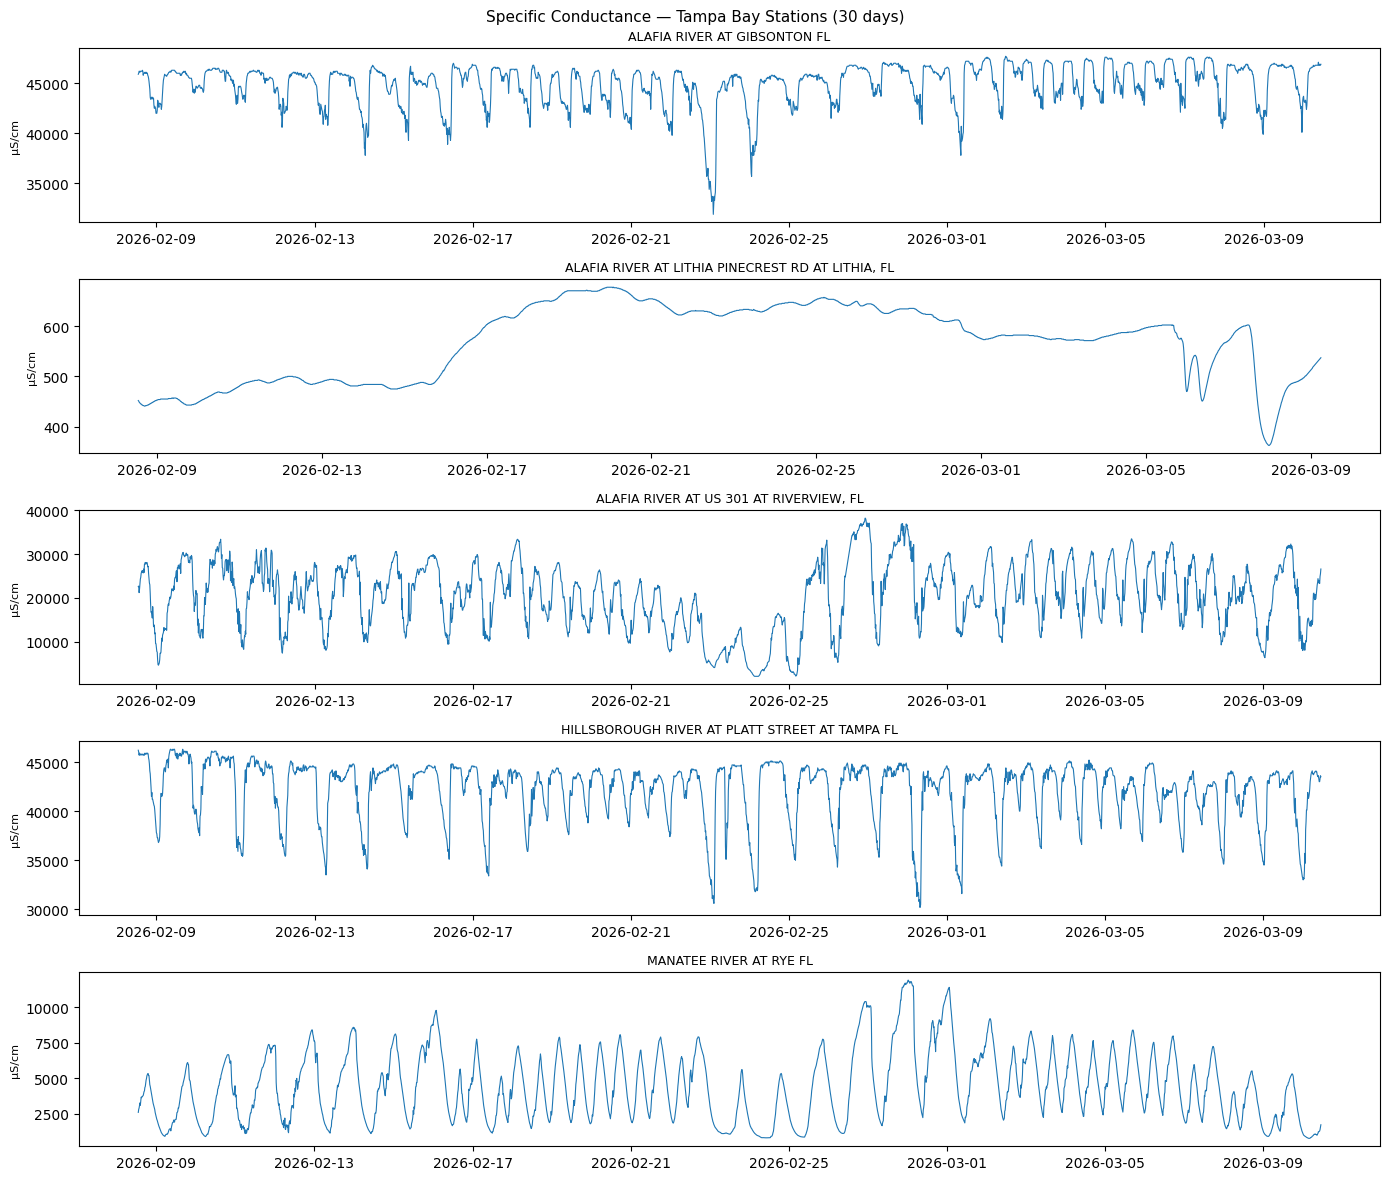

In [10]:
# plot conductance across all stations — do they behave similarly?
conductance = df_all[df_all["param_code"] == "00095"]

fig, axes = plt.subplots(len(conductance["station"].unique()), 1, figsize=(14, 12))

for ax, (station, group) in zip(axes, conductance.groupby("station")):
    ax.plot(group["dateTime"], group["value"], linewidth=0.8)
    ax.set_title(station, fontsize=9)
    ax.set_ylabel("µS/cm", fontsize=8)

plt.suptitle("Specific Conductance — Tampa Bay Stations (30 days)", fontsize=11)
plt.tight_layout()
plt.show()

turbidity records: 2752
['ALAFIA RIVER AT LITHIA PINECREST RD AT LITHIA, FL']


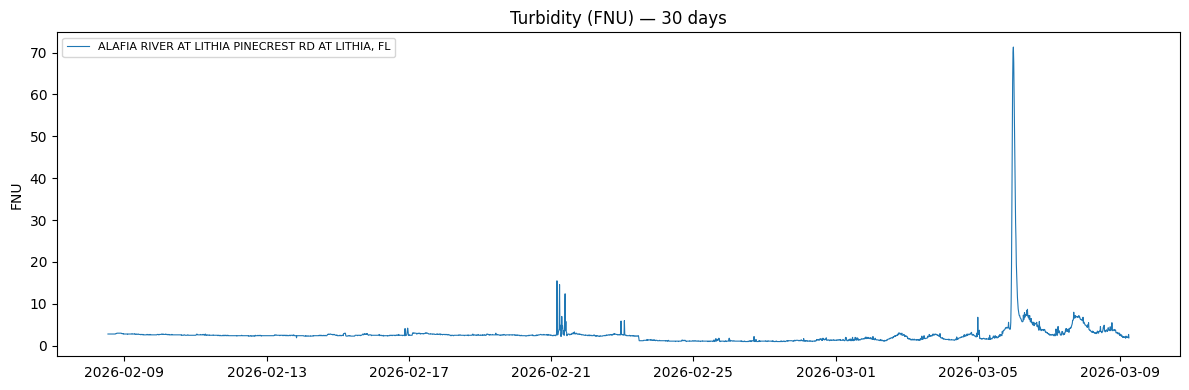

In [11]:
# check turbidity — this is what SkyTL monitors
turbidity = df_all[df_all["param_code"] == "63680"]
print(f"turbidity records: {len(turbidity)}")
print(turbidity["station"].unique())

if len(turbidity) > 0:
    plt.figure(figsize=(12, 4))
    for station, group in turbidity.groupby("station"):
        plt.plot(group["dateTime"], group["value"], label=station, linewidth=0.8)
    plt.title("Turbidity (FNU) — 30 days")
    plt.ylabel("FNU")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("no turbidity data from these stations")

In [13]:
# save cleaned data to csv for the next step (model building)
df_all.to_csv("../data/tampa_bay_raw.csv", index=False)
print(f"saved {len(df_all)} records to data/tampa_bay_raw.csv")

saved 34059 records to data/tampa_bay_raw.csv
